In [1]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
from src.battery import Battery
from src.optimize import run_simulation, get_daily_schedule
from src.load_data import load_data
from src.plot import display_schedule, display_profit, get_stats

import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)


# Battery specs :



- SOC: practical state of charge in [0,1] 
- NEC: practical nominal energy capacity (Wh)
- CR: Charging rate (W/Wh)
- DR: Discharging rate (W/Wh)





In [3]:
SOC = np.array([0, 0.01, 0.85, 1.0])

# Charging curve
CR = np.array([0.25, 0.5, 0.5, 0.1])

SOC_to_CR_function = interp1d(SOC, CR)

# Discharging curve
SOC = np.array([0.0, 0.15, 0.99, 1.0])
DR = np.array([0.1, 0.5, 0.5, 0.25])

SOC_to_DR_function = interp1d(SOC, DR)

bat = Battery(SOC_to_CR_function, SOC_to_DR_function, init_NEC=50000)


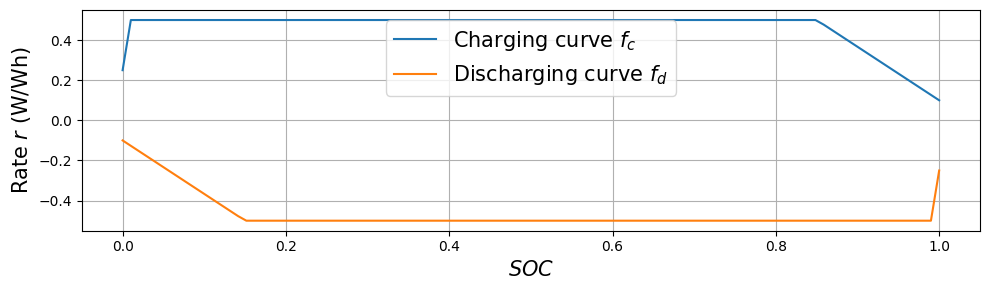

In [4]:
plt.figure(figsize=(10, 3))
plt.plot(
    np.linspace(0, 1, 100),
    SOC_to_CR_function(np.linspace(0, 1, 100)),
    label="Charging curve $f_c$",
)
plt.plot(
    np.linspace(0, 1, 100),
    -SOC_to_DR_function(np.linspace(0, 1, 100)),
    label="Discharging curve $f_d$",
)
plt.grid(True)
plt.xlabel("$SOC$", fontdict=dict(size=15))
plt.ylabel("Rate $r$ (W/Wh)", fontdict=dict(size=15))
plt.legend(loc="upper center", fontsize=15)
plt.tight_layout()
#plt.savefig("out/charging_curve.pdf")
plt.show()


# Dataset :

In [5]:
country = "Germany"


In [6]:
df = load_data(country=country, start="2021-01-01 00:00:00")
df


,Country,ISO3 Code,timestamp,Datetime (Local),price_euros_wh,vgc,fgc
1423428,Germany,DEU,2021-01-01 00:00:00,2021-01-01 01:00:00,4.957000e-05,0.000005,0
1423457,Germany,DEU,2021-01-01 01:00:00,2021-01-01 02:00:00,4.351000e-05,0.000005,0
1423486,Germany,DEU,2021-01-01 02:00:00,2021-01-01 03:00:00,4.083000e-05,0.000005,0
1423515,Germany,DEU,2021-01-01 03:00:00,2021-01-01 04:00:00,3.935000e-05,0.000005,0
1423544,Germany,DEU,2021-01-01 04:00:00,2021-01-01 05:00:00,3.822000e-05,0.000005,0
...,...,...,...,...,...,...,...
1931363,Germany,DEU,2022-12-31 19:00:00,2022-12-31 20:00:00,3.100000e-07,0.000005,0
1931392,Germany,DEU,2022-12-31 20:00:00,2022-12-31 21:00:00,4.800000e-07,0.000005,0
1931421,Germany,DEU,2022-12-31 21:00:00,2022-12-31 22:00:00,1.700000e-07,0.000005,0
1931450,Germany,DEU,2022-12-31 22:00:00,2022-12-31 23:00:00,-6.100000e-07,0.000005,0


# true prices :

In [7]:
prices = [8.403e-05, 8.159e-05, 7.726e-05, 0.0001007, 0.00010069, 0.00012169, 0.00017529, 0.00018617, 0.00019805, 0.00019092, 0.00022007, 0.00021474, 0.0002316, 0.00023367, 0.00023708, 0.00023792, 0.00026, 0.0002556, 0.00022237, 0.00022274, 0.0001778, 0.00014898, 0.00012336, 0.00013025]
vgc = [0.0001] * 24
fgc = [0.0001] * 24
G_c, G_d = bat.max_SOC_change_charge, bat.min_SOC_change_discharge
pv_prod = [0, 0, 0, 0, 0, 0, 1000, 2000, 6000, 10000, 20000, 30000, 35000, 35000, 30000, 20000, 10000, 5000, 2000, 1000, 0, 0, 0, 0]
load_demand = [0, 0, 0, 0, 0, 0, 5000, 10000, 1000, 0, 0, 0, 0, 0, 0, 0, 2000, 2000, 5000, 10000, 5000, 2000, 0, 0]

daily_schedule = get_daily_schedule(prices, vgc, fgc, bat, G_c, G_d, add_pv_and_load=True, pv_prod=pv_prod, load_demand=load_demand, deg_cost=[0.0001])

Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective 22.46525902
266 simplex iterations
1 branching node


In [8]:
num_days = len(df) // 24
df["pv_prod"] = pv_prod * num_days
df["load_demand"] = load_demand * num_days

In [9]:
frame_size_forecast = 28
update_period = 1

df_optim = run_simulation(
    bat,
    start="2022-01-01 00:00:00",
    end="2022-01-03 00:00:00",
    df=df,
    forecasted=False,
    frame_size=frame_size_forecast,
    update_period=update_period,
    add_pv_and_load=True,
    deg_cost=[0.0001],
)

# display_schedule(df_optim, name=country + "_optim_" + str(frame_size_forecast))
# display_profit(df_optim, name=country + "_optim_" + str(frame_size_forecast))


Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective 19.43662924
272 simplex iterations
1 branching node
absmipgap=2.45639e-06, relmipgap=1.26379e-07
Gurobi 13.0.0:Gurobi 13.0.0: optimal solution; objective 12.84600497
493 simplex iterations
1 branching node
absmipgap=0.000410236, relmipgap=3.19349e-05


In [10]:
df_optim

,Country,ISO3 Code,timestamp,Datetime (Local),price_euros_wh,vgc,fgc,pv_prod,load_demand,n_cycles,...,price_forecast,pv_to_grid,pv_to_load,pv_to_bess,grid_to_load,grid_to_bess,bess_to_grid,bess_to_load,capacity,SOC
1677468,Germany,DEU,2022-01-01 00:00:00,2022-01-01 01:00:00,3.139000e-05,0.000005,0,0,0,0.0,...,3.139000e-05,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0
1677497,Germany,DEU,2022-01-01 01:00:00,2022-01-01 02:00:00,2.688000e-05,0.000005,0,0,0,0.0,...,2.688000e-05,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1677526,Germany,DEU,2022-01-01 02:00:00,2022-01-01 03:00:00,2.736000e-05,0.000005,0,0,0,0.0,...,2.736000e-05,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1677555,Germany,DEU,2022-01-01 03:00:00,2022-01-01 04:00:00,2.064000e-05,0.000005,0,0,0,0.0,...,2.064000e-05,0.0,0,0.0,0.0,24804.445613,0.0,0.0,0.0,0.0
1677584,Germany,DEU,2022-01-01 04:00:00,2022-01-01 05:00:00,2.780000e-05,0.000005,0,0,0,0.0,...,2.780000e-05,0.0,0,0.0,0.0,0.0,0.0,0.0,24804.445613,49.608891
1677613,Germany,DEU,2022-01-01 05:00:00,2022-01-01 06:00:00,2.004000e-05,0.000005,0,0,0,0.0,...,2.004000e-05,0.0,0,0.0,0.0,22153.515301,0.0,0.0,24804.445613,49.608891
1677642,Germany,DEU,2022-01-01 06:00:00,2022-01-01 07:00:00,2.228000e-05,0.000005,0,1000,5000,0.0,...,2.228000e-05,0.0,1000,0.0,4000.0,3042.029087,0.0,0.0,46957.960913,93.915922
1677671,Germany,DEU,2022-01-01 07:00:00,2022-01-01 08:00:00,5.513000e-05,0.000005,0,2000,10000,0.0,...,5.513000e-05,0.0,2000,0.0,8000.0,0.01,0.0,0.0,49999.99,99.99998
1677700,Germany,DEU,2022-01-01 08:00:00,2022-01-01 09:00:00,6.928000e-05,0.000005,0,6000,1000,0.0,...,6.928000e-05,5000.0,1000,0.0,0.0,0.0,0.0,0.0,50000.0,100.0
1677729,Germany,DEU,2022-01-01 09:00:00,2022-01-01 10:00:00,7.260000e-05,0.000005,0,10000,0,0.0,...,7.260000e-05,10000.0,0,0.0,0.0,0.0,0.0,0.0,50000.0,100.0
